# Asset-Pricing Model Tests

The discovery of return patterns beyond market beta opened the door to multifactor asset-pricing models. The practical question is no longer only whether a candidate factor earns alpha. It is whether a proposed model can jointly explain the excess returns on a deliberately chosen cross-section of test portfolios.

This notebook compares the CAPM, the Fama–French three-factor model, and the Fama–French five-factor model. We begin with the common theoretical and inferential framework and then apply it to the 5×5 and 2×4×4 portfolios introduced conceptually in Notebook 1 and prepared by the companion replication project.

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from factor_asset_pricing.asset_pricing_tests import factor_regressions, grs_test, pricing_error_summary

pd.options.display.float_format = "{:,.4f}".format
plt.style.use("seaborn-v0_8-whitegrid")
ROOT = Path.cwd().resolve(); ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
DEFAULT_DATA = ROOT.parent / "01_complete/fama-french-five-factor-replication/data/interim/Python"
DATA = Path(os.environ.get("FAP_FF5_DATA_DIR", DEFAULT_DATA))
factors = pd.read_parquet(DATA / "ff5_factors_internal.parquet").set_index("mdate").dropna()
portfolios_5x5 = pd.read_parquet(DATA / "ff5_test_portfolios.parquet")
portfolios_2x4x4 = pd.read_parquet(DATA / "ff_2x4x4_test_portfolios.parquet")

Matplotlib is building the font cache; this may take a moment.


## 1. Multifactor models and empirical model evaluation

### 1.1 From factor evidence to multifactor models

Ross's (1976) Arbitrage Pricing Theory provided an influential motivation for multifactor pricing: with no arbitrage, a sufficiently broad factor structure, and diversifiable idiosyncratic risk, expected returns are approximately linear in systematic exposures rather than market beta alone. A complementary motivation comes from Merton's (1973) Intertemporal CAPM. Investors care not only about current wealth, but also about changes in future investment opportunities. Assets may therefore earn risk premia for covarying with state variables that shift expected returns and volatility, changing the investor's future investment opportunities.

Empirical factors such as size, value, profitability, and investment can be treated as factor-mimicking portfolio returns that summarize common variation or proxy for otherwise difficult-to-observe state variables. However, neither APT nor the ICAPM uniquely identifies these particular factors, and mapping them to specific structural risks is not theoretically unambiguous. Whether they represent priced risks, behavioral mispricing, or useful empirical proxies consequently remains debated.

Even with that caveat, multifactor models are useful empirical benchmarks. They let us ask whether a new factor or a set of test portfolios is explained not only by the market, but also by established characteristic-related return dimensions. The CAPM contains MKT; FF3 adds SMB and HML (Fama and French, 1993); and FF5 adds RMW and CMA (Fama and French, 2015).

The three-factor benchmark here retains SMB from the supplied five-factor dataset. Since FF5 SMB averages the B/M, OP, and INV size spreads, it differs from the original FF3 size factor based on B/M sorts alone. “FF3” therefore denotes the nested MKT–SMB–HML benchmark actually estimated, rather than an exact reconstruction of the 1993 factor definitions.


### 1.2 Time-series regressions: alpha, loadings, and fit

For every test portfolio $i$, we estimate the same general time-series regression:

$$R^e_{i,t}=\alpha_i+\boldsymbol{\beta}_i'\mathbf F_t+\varepsilon_{i,t},$$

where $R^e_{i,t}=R_{i,t}-R_{f,t}$ and $\mathbf F_t$ contains the model's traded factor returns. Alpha is the model's pricing error. For each portfolio, we test

$$H_0:\alpha_i=0 \qquad \text{against} \qquad H_1:\alpha_i\neq0.$$

A significant alpha means that the model does not fully explain that portfolio's average excess return over the sample. In model evaluation, small and statistically insignificant alphas are desirable—the opposite emphasis from a factor-spanning exercise, where researchers seek incremental alpha.

The loading $\beta_{i,k}$ measures portfolio $i$'s partial linear co-movement with factor $k$. We test $H_0:\beta_{i,k}=0$ against $H_1:\beta_{i,k}\neq0$. A significant positive loading indicates positive exposure to that factor return, holding the remaining factors fixed; it does not alone prove that the factor is a structural source of priced risk. Adjusted $R^2$ measures the fraction of monthly variation explained while penalizing additional regressors, but high fit does not guarantee small alphas.

For the population linear projection, $E[\varepsilon_{i,t}]=0$ and $E[\varepsilon_{i,t}\mathbf F_t]=\mathbf0$, giving $\alpha_i=E[R^e_{i,t}]-\boldsymbol\beta_i'E[\mathbf F_t]$. Constant sample loadings are not estimates of conditional betas that vary with the information set. Insignificant alphas can reflect limited power as well as small pricing errors.


### 1.3 Why test portfolios?

A factor model is evaluated on assets chosen to expose economically relevant cross-sectional variation. Sorting stocks into portfolios reduces firm-specific noise while preserving variation in characteristics and expected returns. The design is a balance: portfolios must differ enough to challenge the model, but each cell should contain enough firms for idiosyncratic shocks not to create unstable or spurious alphas.

The 5×5 portfolios independently sort firms into five size groups and five groups of B/M, OP, or INV. The 2×4×4 portfolios first split firms into small and big groups and then form quartiles on two additional characteristics within size. These higher-dimensional portfolios ask whether a model explains one characteristic while conditioning more explicitly on another. Each family is tested separately. GRS does **not** require the portfolios themselves to be uncorrelated—it explicitly uses their residual covariance—but pooling many overlapping families can create redundant assets, an ill-conditioned covariance matrix, and a joint test whose economic content is unclear.

Independent breakpoints do not imply independent characteristics or statistically independent cell returns. In the 2×4×4 construction, both additional characteristics use size-conditioned breakpoints; their intersections need not have equal membership.


### 1.4 Inference and holistic model diagnostics

OLS estimates the alphas and loadings. As in Notebook 2, we report Newey–West standard errors (Newey and West, 1987) with 12 monthly lags because return residuals may be heteroskedastic and autocorrelated. HAC inference changes the estimated covariance matrix and $t$-statistics, not the OLS coefficients. Twelve lags are a transparent one-year convention rather than a universal rule.

No single statistic fully describes model performance. We therefore report the average absolute alpha and average adjusted $R^2$ for each portfolio family:

$$A(|\alpha|)=\frac{1}{N}\sum_{i=1}^{N}|\widehat{\alpha}_i|,\qquad A(\bar R^2)=\frac{1}{N}\sum_{i=1}^{N}\bar R_i^2.$$

Absolute values prevent positive and negative pricing errors from cancelling. Lower $A(|\alpha|)$ indicates smaller average pricing errors, while higher $A(\bar R^2)$ indicates stronger average time-series fit. We also retain root-mean-squared alpha because it places more weight on unusually large pricing errors.

Individual significance counts use unadjusted coefficient tests and should be read descriptively when many portfolios are tested. The joint GRS restriction addresses the alpha vector as a whole under its separate assumptions.


### 1.5 The Gibbons–Ross–Shanken joint test

Gibbons, Ross, and Shanken (1989) test

$$H_0:\boldsymbol\alpha=\mathbf0,\qquad H_1:\text{at least one }\alpha_i\ne0.$$

Let $T$ be the common sample size, $N$ the number of test assets, and $K$ the number of factors. Let $E$ be the $T\times N$ OLS residual matrix, $F_c$ the demeaned $T\times K$ factor matrix, and $\bar{\mathbf F}$ the factor mean. With both covariances normalized by $T$,

$$\widehat\Sigma_T=E'E/T,\qquad \widehat\Omega_T=F_c'F_c/T,$$

$$GRS=\frac{T-N-K}{N}\frac{\widehat{\boldsymbol\alpha}'\widehat\Sigma_T^{-1}\widehat{\boldsymbol\alpha}}{1+\bar{\mathbf F}'\widehat\Omega_T^{-1}\bar{\mathbf F}}.$$

The implementation instead uses $S=E'E/(T-K-1)$ and $\Omega=F_c'F_c/(T-1)$. Since $\widehat\Sigma_T=(T-K-1)S/T$ and $\widehat\Omega_T=(T-1)\Omega/T$, the identical statistic is

$$GRS=\frac{T(T-N-K)}{N(T-K-1)}\frac{\widehat{\boldsymbol\alpha}'S^{-1}\widehat{\boldsymbol\alpha}}{1+\frac{T}{T-1}\bar{\mathbf F}'\Omega^{-1}\bar{\mathbf F}}.$$

Under $H_0$, $GRS\sim F_{N,T-N-K}$ when errors are iid multivariate normal, with constant nonsingular covariance and independence from the factor regressors. The design must have full rank, the relevant covariances must be invertible, and $T>N+K$. Correlated residuals across portfolios are allowed. Heteroskedasticity and serial dependence invalidate this conventional exact reference distribution; the separate HAC regressions do not make GRS robust.

Rejection means the model fails to jointly price this portfolio family. Failure to reject does not prove that the model is true or complete. For traded factors and unrestricted portfolios with a risk-free asset, the restriction also characterizes mean–variance efficiency relative to the added test assets; it does not assert exact return replication. We interpret the joint test alongside HAC individual-alpha inference and economic pricing-error magnitudes.


## 2. Example: Comparing CAPM, FF3, and FF5

We now apply the common testing framework to the characteristic-sorted portfolios introduced conceptually in Notebook 1 and prepared by the companion replication project. The comparison begins holistically across all six portfolio families before examining the alpha and loading patterns inside the 5×5 and 2×4×4 sorts.

### 2.1 Holistic comparison across portfolio families

In [2]:
models = {"CAPM": ["MKT"], "FF3": ["MKT", "SMB", "HML"], "FF5": ["MKT", "SMB", "HML", "RMW", "CMA"]}
labels = {"size_bm": "Size × B/M", "size_op": "Size × OP", "size_inv": "Size × INV", "size_bm_op": "Size × B/M × OP", "size_bm_inv": "Size × B/M × INV", "size_op_inv": "Size × OP × INV"}
portfolio_sets = {}
for family, data in portfolios_5x5.groupby("family"):
    data = data.copy(); data["asset"] = "S" + data.row_portfolio.astype(int).astype(str) + "C" + data.column_portfolio.astype(int).astype(str)
    portfolio_sets[family] = data.pivot(index="mdate", columns="asset", values="ret").sort_index()
for family, data in portfolios_2x4x4.groupby("family"):
    data = data.copy(); data["asset"] = data.size_portfolio.astype(str) + "-" + data.characteristic_1_portfolio.astype(int).astype(str) + "-" + data.characteristic_2_portfolio.astype(int).astype(str)
    portfolio_sets[family] = data.pivot(index="mdate", columns="asset", values="ret").sort_index()

aligned = {}; regressions = {}; joint_tests = {}; rows = []
for family, returns in portfolio_sets.items():
    sample = pd.concat([returns, factors], axis=1, join="inner").dropna()
    assets = sample[returns.columns].sub(sample["RF"], axis=0); aligned[family] = (assets, sample)
    for model, columns in models.items():
        result = factor_regressions(assets, sample[columns], cov_type="HAC", hac_lags=12); regressions[family, model] = result
        grs = grs_test(assets, sample[columns]); joint_tests[family, model] = grs
        errors = pricing_error_summary(result)
        rows.append({"Portfolio set": labels[family], "Model": model, "Mean |alpha| (% monthly)": 100*errors["mean_absolute_alpha"], "RMSE alpha (% monthly)": 100*errors["root_mean_squared_alpha"], "Mean adjusted R²": result.adjusted_r_squared.mean(), "Significant alphas (5%)": int((result.alpha_pvalue < .05).sum()), "GRS": grs["statistic"], "GRS p-value": grs["pvalue"]})
overview = pd.DataFrame(rows).set_index(["Portfolio set", "Model"]); display(overview)

Mean |alpha| (% monthly)  RMSE alpha (% monthly)  \
Portfolio set    Model                                                     
Size × B/M       CAPM                     0.1693                  0.2171   
                 FF3                      0.0864                  0.1215   
                 FF5                      0.0825                  0.0954   
Size × INV       CAPM                     0.1887                  0.2040   
                 FF3                      0.0948                  0.1315   
                 FF5                      0.0710                  0.0991   
Size × OP        CAPM                     0.1771                  0.1985   
                 FF3                      0.1117                  0.1414   
                 FF5                      0.0527                  0.0595   
Size × B/M × INV CAPM                     0.1830                  0.2179   
                 FF3                      0.1070                  0.1277   
                 FF5                      0.0839                  0.1068   
Size × B/M × OP  CAPM                     0.2143                  0.2762   
                 FF3                      0.1331                  0.1787   
                 FF5                      0.1098                  0.1418   
Size × OP × INV  CAPM                     0.2229                  0.2778   
                 FF3                      0.1738                  0.2192   
                 FF5                      0.0900                  0.1172   

                        Mean adjusted R²  Significant alphas (5%)    GRS  \
Portfolio set    Model                                                     
Size × B/M       CAPM             0.7319                        6 2.9103   
                 FF3              0.9088                        3 2.5501   
                 FF5              0.9120                        5 2.1421   
Size × INV       CAPM             0.7720                        7 4.2269   
                 FF3              0.9119                        7 4.1921   
                 FF5              0.9231                        6 2.9791   
Size × OP        CAPM             0.7711                        3 1.7756   
                 FF3              0.8971                        7 1.9362   
                 FF5              0.9169                        0 1.1538   
Size × B/M × INV CAPM             0.7119                        6 2.7926   
                 FF3              0.8619                        8 2.6194   
                 FF5              0.8743                        7 2.0925   
Size × B/M × OP  CAPM             0.6889                        4 1.9641   
                 FF3              0.8392                        8 1.8483   
                 FF5              0.8544                        4 1.5043   
Size × OP × INV  CAPM             0.7384                       16 4.1719   
                 FF3              0.8550                       19 3.9984   
                 FF5              0.8778                        8 2.2471   

                        GRS p-value  
Portfolio set    Model               
Size × B/M       CAPM        0.0000  
                 FF3         0.0001  
                 FF5         0.0011  
Size × INV       CAPM        0.0000  
                 FF3         0.0000  
                 FF5         0.0000  
Size × OP        CAPM        0.0116  
                 FF3         0.0042  
                 FF5         0.2755  
Size × B/M × INV CAPM        0.0000  
                 FF3         0.0000  
                 FF5         0.0005  
Size × B/M × OP  CAPM        0.0013  
                 FF3         0.0034  
                 FF5         0.0382  
Size × OP × INV  CAPM        0.0000  
                 FF3         0.0000  
                 FF5         0.0001

Across all six portfolio families, FF5 produces lower average absolute alpha and higher average adjusted $R^2$ than CAPM. The improvement is especially clear for portfolios involving profitability or investment, the two dimensions added to FF3. The comparison is not a mechanical reward for adding regressors: adjusted $R^2$ penalizes model size, while alpha remains the economically relevant pricing error. FF5 nevertheless remains imperfect. GRS rejects it for five of the six families at the 5% level; only the Size × OP portfolios fail to reject joint zero alpha.

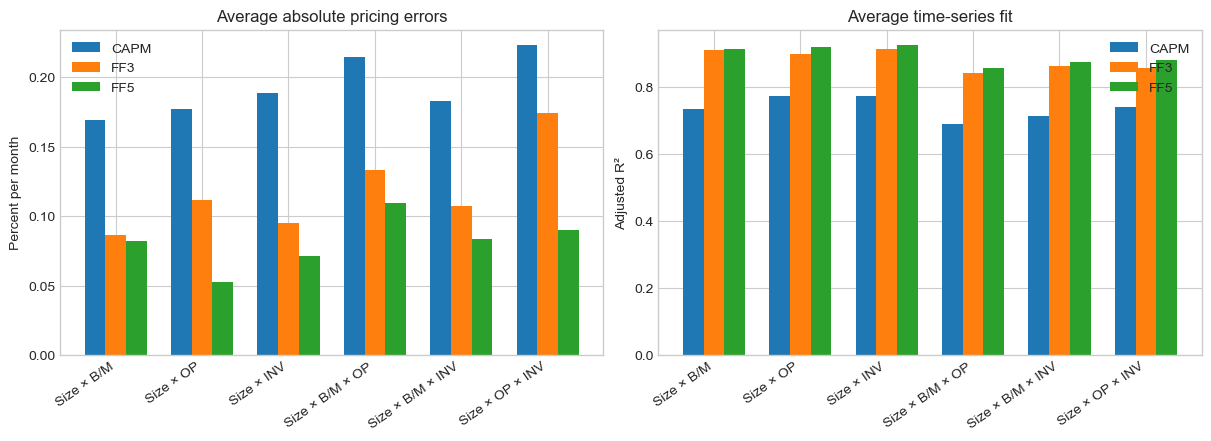

In [3]:
plot_data = overview.reset_index(); order = list(labels.values()); x = np.arange(len(order)); width = .24
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), constrained_layout=True)
for offset, model in zip([-width, 0, width], models):
    data = plot_data.set_index(["Portfolio set", "Model"]).loc[[(name, model) for name in order]].reset_index()
    axes[0].bar(x + offset, data["Mean |alpha| (% monthly)"], width, label=model)
    axes[1].bar(x + offset, data["Mean adjusted R²"], width, label=model)
for ax in axes: ax.set_xticks(x, order, rotation=35, ha="right"); ax.legend(frameon=False)
axes[0].set(title="Average absolute pricing errors", ylabel="Percent per month"); axes[1].set(title="Average time-series fit", ylabel="Adjusted R²"); plt.show()

The visual comparison shows a broad rather than isolated improvement: moving from CAPM to FF3 and then FF5 generally compresses absolute alphas while increasing explanatory power. The remaining gap between small pricing errors and widespread GRS rejection illustrates why model evaluation should not be reduced to a single pass–fail statistic.

### 2.2 The 5×5 test portfolios

The 5×5 portfolios provide 25 test assets for each characteristic family. The alpha heatmaps retain the economic layout of the sorts: rows move from small to big firms, and columns move from low to high B/M, OP, or INV. A successful model should flatten systematic color gradients rather than merely reduce one extreme portfolio's alpha.

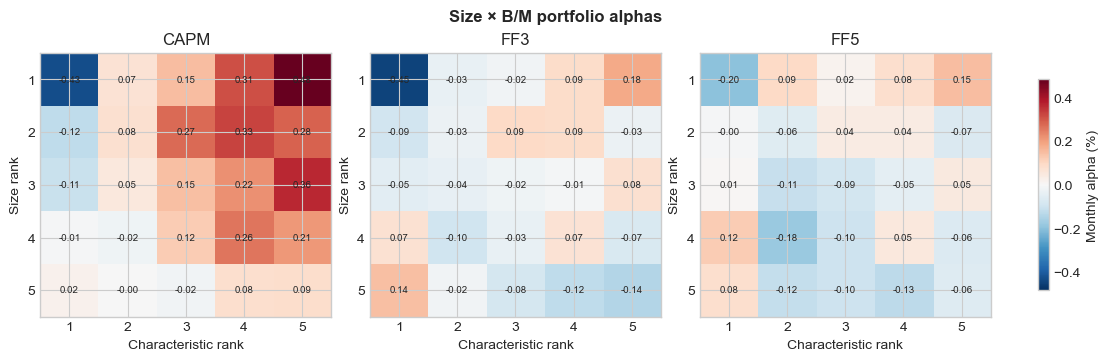

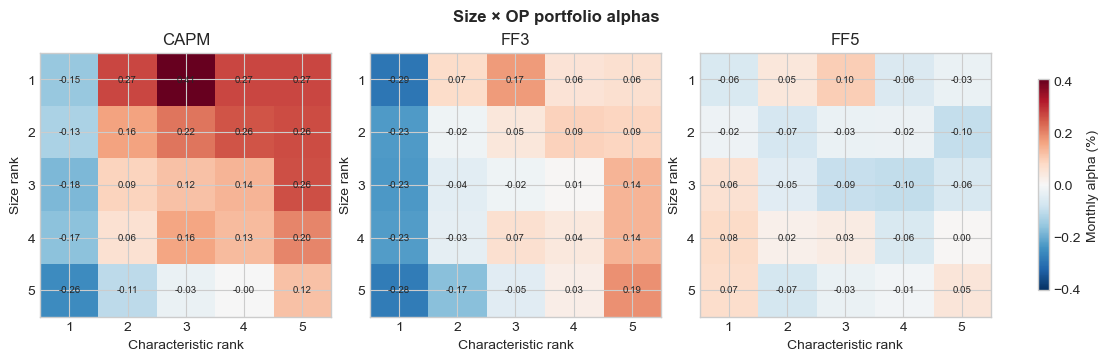

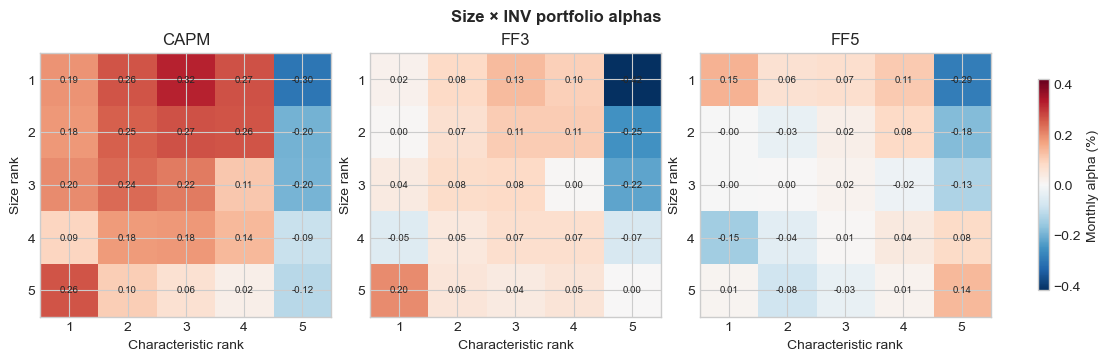

In [4]:
def alpha_grid_5x5(family, model):
    values = regressions[family, model].alpha.rename_axis("asset").reset_index(); values[["size", "characteristic"]] = values.asset.str.extract(r"S(\d)C(\d)").astype(int); return values.pivot(index="size", columns="characteristic", values="alpha") * 100

for family in ["size_bm", "size_op", "size_inv"]:
    grids = {model: alpha_grid_5x5(family, model) for model in models}; bound = max(abs(grid.to_numpy()).max() for grid in grids.values())
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), constrained_layout=True)
    for ax, (model, grid) in zip(axes, grids.items()):
        image = ax.imshow(grid, cmap="RdBu_r", vmin=-bound, vmax=bound, aspect="auto")
        for (r, c), value in np.ndenumerate(grid.to_numpy()): ax.text(c, r, f"{value:.2f}", ha="center", va="center", fontsize=7)
        ax.set(title=model, xlabel="Characteristic rank", ylabel="Size rank", xticks=range(5), xticklabels=range(1,6), yticks=range(5), yticklabels=range(1,6))
    fig.colorbar(image, ax=axes, shrink=.8, label="Monthly alpha (%)"); fig.suptitle(f"{labels[family]} portfolio alphas", weight="bold"); plt.show()

For Size × B/M, FF3 removes much of the CAPM pattern and FF5 produces only a modest further reduction in average absolute alpha. The profitability and investment families make the incremental role of FF5 clearer: RMW and CMA reduce the corresponding alpha gradients, lower average pricing errors, and raise adjusted $R^2$. Size × OP is the strongest result—FF5 leaves no individually significant alphas at 5% and the GRS test fails to reject jointly. Size × B/M and Size × INV still reject, so the additional factors improve these cross-sections without fully pricing them.

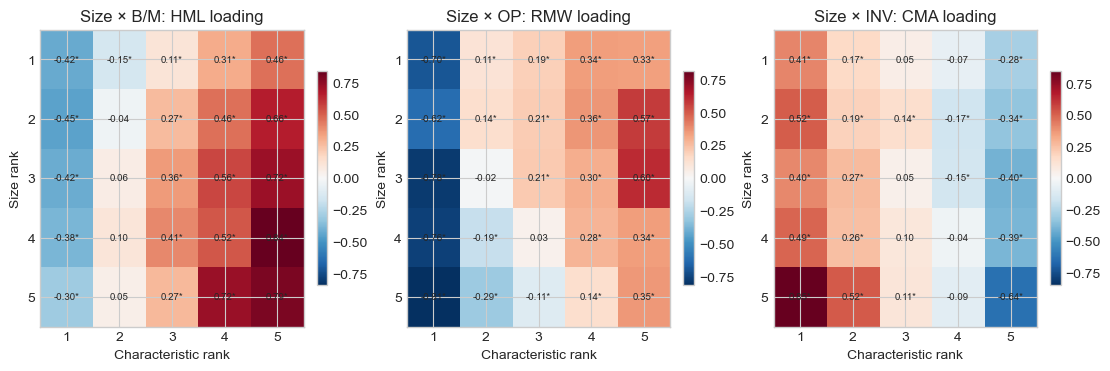

In [5]:
loading_specs = {"size_bm": "HML", "size_op": "RMW", "size_inv": "CMA"}
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), constrained_layout=True)
for ax, (family, factor) in zip(axes, loading_specs.items()):
    result = regressions[family, "FF5"]; values = result[[f"beta_{factor}", f"beta_{factor}_t"]].rename_axis("asset").reset_index(); values[["size", "characteristic"]] = values.asset.str.extract(r"S(\d)C(\d)").astype(int); grid = values.pivot(index="size", columns="characteristic", values=f"beta_{factor}"); t_grid = values.pivot(index="size", columns="characteristic", values=f"beta_{factor}_t")
    bound = abs(grid.to_numpy()).max(); image = ax.imshow(grid, cmap="RdBu_r", vmin=-bound, vmax=bound, aspect="auto")
    for (r, c), value in np.ndenumerate(grid.to_numpy()): ax.text(c, r, f"{value:.2f}{'*' if abs(t_grid.to_numpy()[r,c]) >= 1.96 else ''}", ha="center", va="center", fontsize=7)
    ax.set(title=f"{labels[family]}: {factor} loading", xlabel="Characteristic rank", ylabel="Size rank", xticks=range(5), xticklabels=range(1,6), yticks=range(5), yticklabels=range(1,6)); fig.colorbar(image, ax=ax, shrink=.72)
plt.show()

The loading gradients make the mechanism behind the improved fit visible. HML exposure rises across B/M portfolios, RMW exposure rises across profitability portfolios, and CMA exposure rises toward conservative-investment portfolios. An asterisk marks a loading with an absolute Newey–West $t$-statistic of at least 1.96. Their alignment with the sorting characteristic shows that the factors capture variation associated with the intended characteristics; it does not by itself establish why those dimensions command risk premia.

### 2.3 The 2×4×4 test portfolios

The 32-portfolio families provide a more conditional challenge. Within small and big firms, they preserve joint variation in two characteristics. Each figure displays small and big firms in separate rows and compares CAPM, FF3, and FF5 in columns.

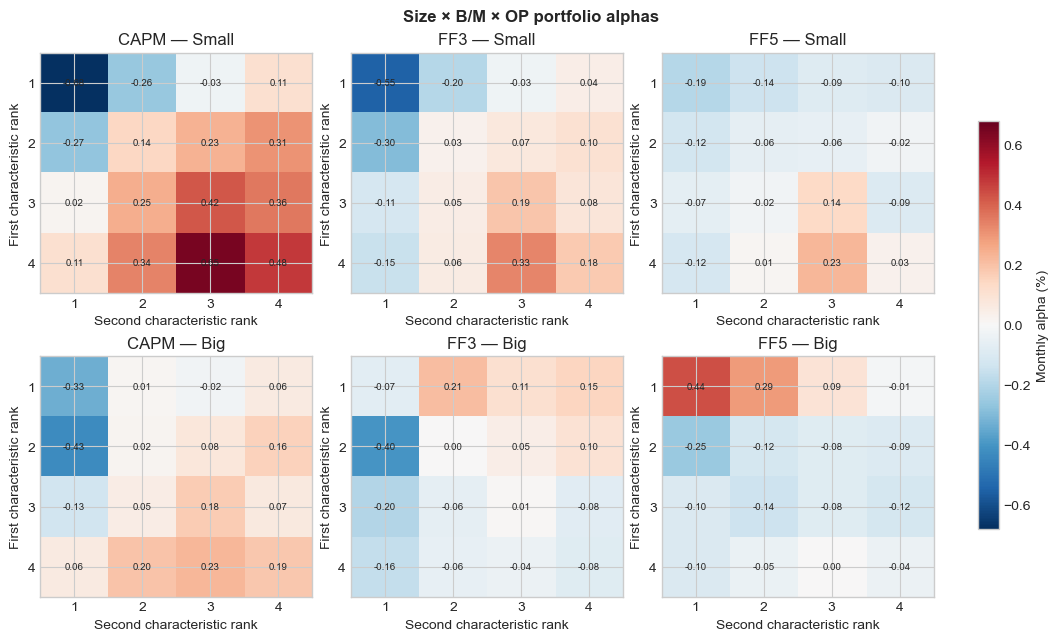

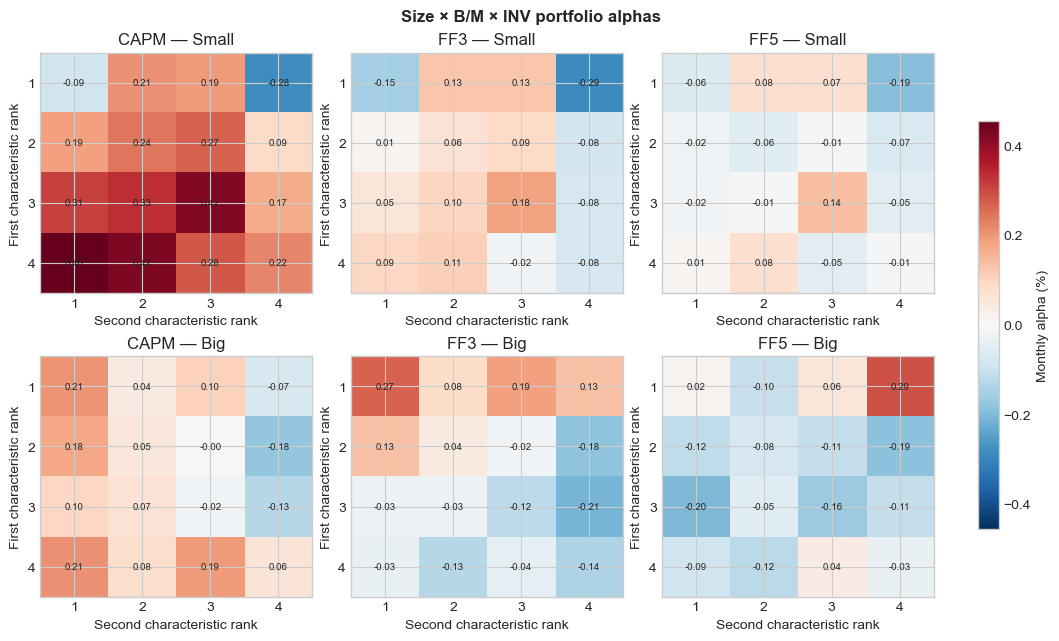

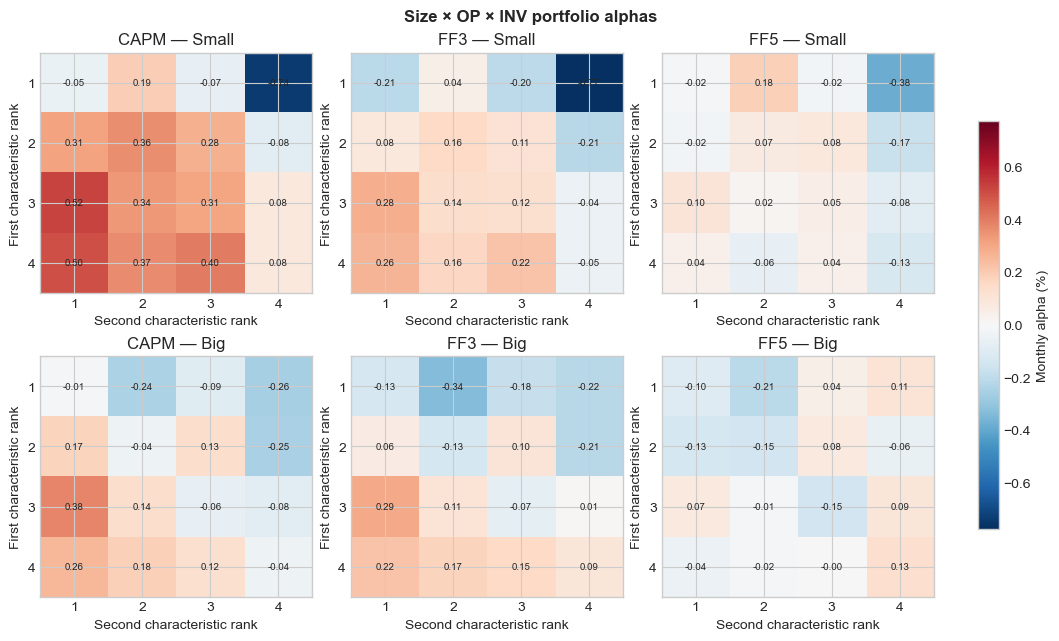

In [6]:
def alpha_grid_2x4x4(family, model, size):
    values = regressions[family, model].alpha.rename_axis("asset").reset_index(); parsed = values.asset.str.extract(r"([SB])-(\d)-(\d)"); values[["size", "first", "second"]] = parsed; values[["first", "second"]] = values[["first", "second"]].astype(int); return values.loc[values["size"].eq(size)].pivot(index="first", columns="second", values="alpha") * 100

for family in ["size_bm_op", "size_bm_inv", "size_op_inv"]:
    grids = {(size, model): alpha_grid_2x4x4(family, model, size) for size in ["S", "B"] for model in models}; bound = max(abs(grid.to_numpy()).max() for grid in grids.values())
    fig, axes = plt.subplots(2, 3, figsize=(10.5, 6.3), constrained_layout=True)
    for row, size in enumerate(["S", "B"]):
        for col, model in enumerate(models):
            ax = axes[row, col]; grid = grids[size, model]; image = ax.imshow(grid, cmap="RdBu_r", vmin=-bound, vmax=bound, aspect="auto")
            for (r, c), value in np.ndenumerate(grid.to_numpy()): ax.text(c, r, f"{value:.2f}", ha="center", va="center", fontsize=7)
            ax.set(title=f"{model} — {'Small' if size == 'S' else 'Big'}", xlabel="Second characteristic rank", ylabel="First characteristic rank", xticks=range(4), xticklabels=range(1,5), yticks=range(4), yticklabels=range(1,5))
    fig.colorbar(image, ax=axes, shrink=.75, label="Monthly alpha (%)"); fig.suptitle(f"{labels[family]} portfolio alphas", weight="bold"); plt.show()

The conditional portfolios tell the same broad story but impose a harder test. FF5 materially reduces CAPM pricing errors in every family, especially Size × OP × INV, yet the remaining alphas are not uniformly zero. GRS rejects all three FF5 specifications at 5%, although Size × B/M × OP is close to the threshold. Conditioning reveals residual pockets of model failure that can be hidden by averages, particularly where characteristic combinations produce more extreme exposures.

In [7]:
factor_pairs = {"size_bm_op": [("first", "HML"), ("second", "RMW")], "size_bm_inv": [("first", "HML"), ("second", "CMA")], "size_op_inv": [("first", "RMW"), ("second", "CMA")]}
loading_rows = []
for family, pairs in factor_pairs.items():
    result = regressions[family, "FF5"].reset_index(); parsed = result.asset.str.extract(r"([SB])-(\d)-(\d)"); result[["size", "first", "second"]] = parsed; result[["first", "second"]] = result[["first", "second"]].astype(int)
    for dimension, factor in pairs:
        averages = result.groupby(dimension)[f"beta_{factor}"].mean(); loading_rows.append({"Portfolio set": labels[family], "Sorting dimension": dimension.title(), "Matching factor": factor, "Low-rank beta": averages.loc[1], "High-rank beta": averages.loc[4], "High − low beta": averages.loc[4] - averages.loc[1]})
display(pd.DataFrame(loading_rows).set_index(["Portfolio set", "Matching factor"]))

Sorting dimension  Low-rank beta  \
Portfolio set    Matching factor                                    
Size × B/M × OP  HML                         First        -0.3311   
                 RMW                        Second        -0.5098   
Size × B/M × INV HML                         First        -0.2942   
                 CMA                        Second         0.5521   
Size × OP × INV  RMW                         First        -0.5531   
                 CMA                        Second         0.5302   

                                  High-rank beta  High − low beta  
Portfolio set    Matching factor                                   
Size × B/M × OP  HML                      0.7473           1.0784  
                 RMW                      0.3776           0.8874  
Size × B/M × INV HML                      0.7149           1.0091  
                 CMA                     -0.3998          -0.9519  
Size × OP × INV  RMW                      0.4073           0.9604  
                 CMA                     -0.4377          -0.9678

The loading spreads confirm that the conditional sorts generate the intended risk-exposure variation. Moving from low to high B/M or OP increases exposure to HML or RMW. Investment is ordered from low investment (conservative) to high investment (aggressive), so CMA exposure moves in the opposite direction and becomes more negative as the investment rank rises. This is precisely why the portfolios are informative test assets: they create a broad range of model-implied exposures while remaining diversified portfolios rather than individual stocks.

### 2.4 What the tests establish

The FF5 model improves materially on CAPM and generally on FF3 for these characteristic-sorted portfolios: average absolute alphas fall, adjusted $R^2$ rises, and characteristic-factor loadings align with the portfolios' sorting dimensions. The improvement is strongest when profitability and investment are present.

The conclusion remains deliberately limited. Most GRS tests still reject joint zero alpha, so FF5 is not a complete description of every tested cross-section. Conversely, rejection does not identify whether the failure reflects omitted risk, mispricing, measurement error, or the particular sample and test assets. These tests rank empirical models by how well they organize returns; they do not settle the economic origin of the factors.

## References

- Fama, E. F., and French, K. R. (1993). Common risk factors in the returns on stocks and bonds. *Journal of Financial Economics*, 33(1), 3–56. [DOI](https://doi.org/10.1016/0304-405X(93)90023-5).

- Fama, E. F., and French, K. R. (2015). A five-factor asset pricing model. *Journal of Financial Economics*, 116(1), 1–22. [DOI](https://doi.org/10.1016/j.jfineco.2014.10.010).

- Gibbons, M. R., Ross, S. A., and Shanken, J. (1989). A test of the efficiency of a given portfolio. *Econometrica*, 57(5), 1121–1152. [DOI](https://doi.org/10.2307/1913625).

- Merton, R. C. (1973). An intertemporal capital asset pricing model. *Econometrica*, 41(5), 867–887. [DOI](https://doi.org/10.2307/1913811).

- Newey, W. K., and West, K. D. (1987). A simple, positive semi-definite, heteroskedasticity and autocorrelation consistent covariance matrix. *Econometrica*, 55(3), 703–708. [DOI](https://doi.org/10.2307/1913610).

- Ross, S. A. (1976). The arbitrage theory of capital asset pricing. *Journal of Economic Theory*, 13(3), 341–360. [DOI](https://doi.org/10.1016/0022-0531(76)90046-6).
